In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from tabpfn import TabPFNClassifier
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import AllChem, DataStructs
import numpy as np
import torch

In [2]:
train=pd.read_csv('/home/ychen3338/proj_2/tox/tox_train.csv')
test=pd.read_csv('/home/ychen3338/proj_2/tox/tox_test.csv')

In [3]:
class morgan_fp:
    def __init__(self, radius, length):
        self.radius = radius
        self.length = length
    def __call__(self, smiles):
        mol = Chem.MolFromSmiles(smiles)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, self.radius, self.length)
        npfp = np.array(list(fp.ToBitString())).astype('float32')
        return npfp

In [4]:
def conv_data(data, fp):
    data['c-fp'] = data['Cation'].apply(fp)
    x_c=np.array(list(data['c-fp']))
    data['a-fp'] = data['Anion'].apply(fp)
    x_a=np.array(list(data['a-fp']))
    xx = np.concatenate([x_c, x_a], axis =1)
    y = data['logEC50'].values
    return xx, y

In [5]:
params ={'bagging_temperature': 164.9929320084992, 'depth': 5,
          'fp_length': 1097, 'fp_radius': 2,
            'iterations': 954, 'l2_leaf_reg': 3.0688155491904245, 
            'learning_rate': 0.024819698205080988, 
            'random_strength': 74.8366958504647}

In [26]:
# params ={'bagging_temperature': 99.78911775925717, 'depth': 6, 
#          'fp_length': 3408, 'fp_radius': 2, 
#          'iterations': 938, 'l2_leaf_reg': 13.441733974137511, 
#          'learning_rate': 0.024817136457158606, 
#          'random_strength': 1.0648821763786775}

In [6]:
fp = morgan_fp(params['fp_radius'], params['fp_length'])

In [7]:
X_train, y_train = conv_data(train, fp)
X_test, y_test = conv_data(test, fp)


[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerator
[01:18:01] DEPRECATION WARNING: please use MorganGenerat

In [8]:
num_bins = 8
all_y = np.concatenate([y_train, y_test])
bins = np.linspace(all_y.min(), all_y.max(), num_bins + 1)

y_train_bin = np.digitize(y_train, bins) - 1
y_test_bin = np.digitize(y_test, bins) - 1

all_bin = np.concatenate([y_train_bin, y_test_bin])
le = LabelEncoder()
all_encoded = le.fit_transform(all_bin)
y_train_enc = all_encoded[:len(y_train)]
y_test_enc = all_encoded[len(y_train):]

In [9]:
num_bins = 9  # 修改为跟 proba.shape[1] 一致
bins = np.linspace(all_y.min(), all_y.max(), num_bins + 1)

y_train_bin = np.digitize(y_train, bins) - 1
y_test_bin = np.digitize(y_test, bins) - 1

# 确保不超出 bin 数范围
y_train_bin[y_train_bin >= num_bins] = num_bins - 1
y_test_bin[y_test_bin >= num_bins] = num_bins - 1

# Label encoding
all_bin = np.concatenate([y_train_bin, y_test_bin])
le = LabelEncoder()
all_encoded = le.fit_transform(all_bin)
y_train_enc = all_encoded[:len(y_train)]
y_test_enc = all_encoded[len(y_train):]

# bin centers 正确构建
bin_centers = 0.5 * (bins[:-1] + bins[1:])


In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
model = TabPFNClassifier(device=device, ignore_pretraining_limits=True)
model.fit(X_train, y_train_enc)

Using device: cuda


/home/ychen3338/miniconda3/envs/ml/lib/python3.10/site-packages/tabpfn/classifier.py:422: UserWarning: Number of features 2194 is greater than the maximum Number of features 500 supported by the model. You may see degraded performance.
  X, y, feature_names_in, n_features_in = validate_Xy_fit(


TabPFNClassifier(device='cuda', ignore_pretraining_limits=True)

In [11]:
proba = model.predict_proba(X_test)

bin_centers = 0.5 * (bins[:-1] + bins[1:])

regression_preds = np.dot(proba, bin_centers)


In [12]:
r2 = r2_score(y_test, regression_preds)
rmse = mean_squared_error(y_test, regression_preds, squared=False)
print(f"R² score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² score: 0.6578
RMSE: 0.6157


/home/ychen3338/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


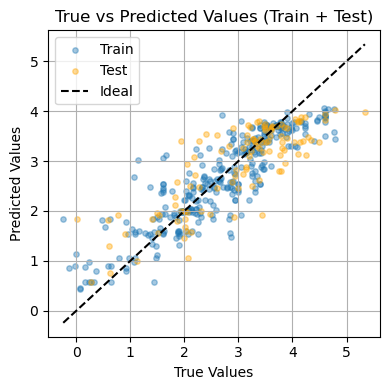

In [14]:
# 训练集预测
train_proba = model.predict_proba(X_train)
y_train_pred = np.dot(train_proba, bin_centers)

# 测试集预测已得：regression_preds = y_test_pred
y_test_pred = regression_preds

# 绘图
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))

plt.scatter(y_train, y_train_pred, label='Train', alpha=0.4, s=15)
plt.scatter(y_test, y_test_pred, label='Test', alpha=0.4, s=15, color='orange')

min_val = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal')

plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted Values (Train + Test)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


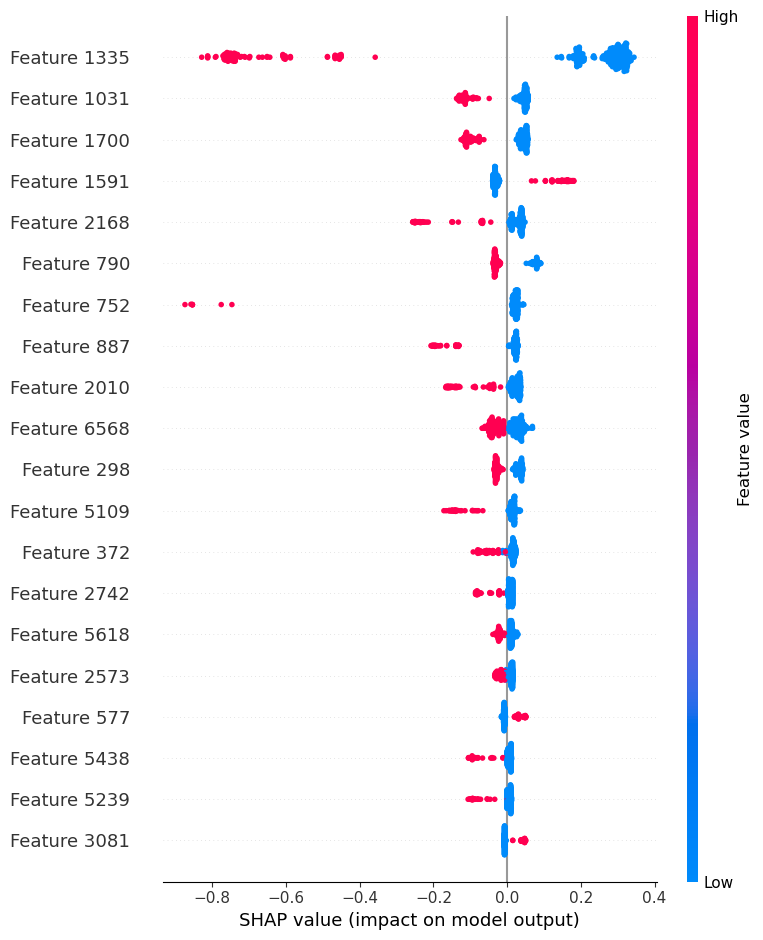

In [15]:
import shap
from catboost import CatBoostRegressor

# 训练 surrogate 模型
surrogate = CatBoostRegressor(verbose=0)
surrogate.fit(X_train, y_train_pred)  # 使用 TabPFN 的训练预测结果作为目标

# SHAP 分析 surrogate 模型
explainer = shap.Explainer(surrogate)
shap_values = explainer(X_train)

# 绘制 SHAP summary
shap.summary_plot(shap_values, X_train, max_display=20, show=False)
plt.tight_layout()
plt.show()


In [16]:
# Convert SHAP values to a DataFrame
shap_values_df = pd.DataFrame(shap_values.values, columns=[f'Position_{i}' for i in range(X_train.shape[1])])

# Initialize a list to store mean SHAP values for positions where MF == 1
mean_shap_values = []

# Iterate over each position (feature) in the fingerprint
for i in range(X_train.shape[1]):
    # Filter SHAP values where the feature (fingerprint position) is set to 1
    shap_values_at_1 = shap_values_df[X_train[:, i] == 1][f'Position_{i}']

    # Calculate the mean SHAP value at this position when MF == 1
    mean_shap_value = shap_values_at_1.mean()
    mean_shap_values.append(mean_shap_value)

# Create a DataFrame to store the result
mean_shap_df = pd.DataFrame({
    'Position': range(len(mean_shap_values)),
    'Mean_SHAP_Value': mean_shap_values
})

print(mean_shap_df)

      Position  Mean_SHAP_Value
0            0              0.0
1            1              0.0
2            2              NaN
3            3              NaN
4            4              0.0
...        ...              ...
6811      6811              NaN
6812      6812              NaN
6813      6813              NaN
6814      6814              NaN
6815      6815              NaN

[6816 rows x 2 columns]


In [17]:
mean_shap_df.to_csv('/home/ychen3338/proj_2/tox/shap_feature_tox.csv', index=False)

In [18]:
mean_shap_df= pd.read_csv('/home/ychen3338/proj_2/tox/shap_feature_tox.csv')

In [19]:
mean_shap_df['Negative_Impact'] = (mean_shap_df['Mean_SHAP_Value'] < 0).astype(int)
output_cols = ['Position', 'Negative_Impact']
mean_shap_df[output_cols].to_csv('shap_negative_flags.csv', index=False)

In [20]:
tox_opt_df = pd.read_csv('/home/ychen3338/proj_2/tox/shap_negative_flags.csv')
positive_bits = tox_opt_df['Negative_Impact'].values